<div
  style="
    background-color: #f0f0f0;
    color:rgb(56, 56, 56);
    padding: 8px;
    display: flex;
    align-items: center;
    gap: 100px;
  "
>
  <img src="../../../images/brand.svg" style="max-height: 80px;">
  <strong>
    AI Saga: Data Science and Machine Learning</br>
    3.lab.2. Auto MPG Regression - Neural Networks
  </strong>
</div>

### Background

You will continue working with the Auto MPG dataset, implementing neural networks using PyTorch for regression.

The dataset includes:
- 398 instances
- 8 attributes including MPG, cylinders, displacement, horsepower, weight, acceleration, model year and origin

### Description

Your task is to implement neural networks using PyTorch to:

- Design and implement a regression neural network
- Experiment with different network depths and widths
- Compare performance with previous regression models
- Visualize the learning process and predictions

### Deliverables

- A **ipynb** (Jupyter Notebook) file called **auto-mpg-regression-nn.ipynb**
- Visualizations of training progress and final predictions
- Comparison with linear/polynomial regression from week 2
- Use the provided template as a starting point

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Carregar e Explorar o Dataset

In [ ]:
df = load_dataset("mpg")
print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())
df.head()

Dataset shape: (398, 9)

Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
df = df.dropna()
print(f'Dataset shape after dropping NaN: {df.shape}')

Dataset shape after dropping NaN: (392, 9)


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


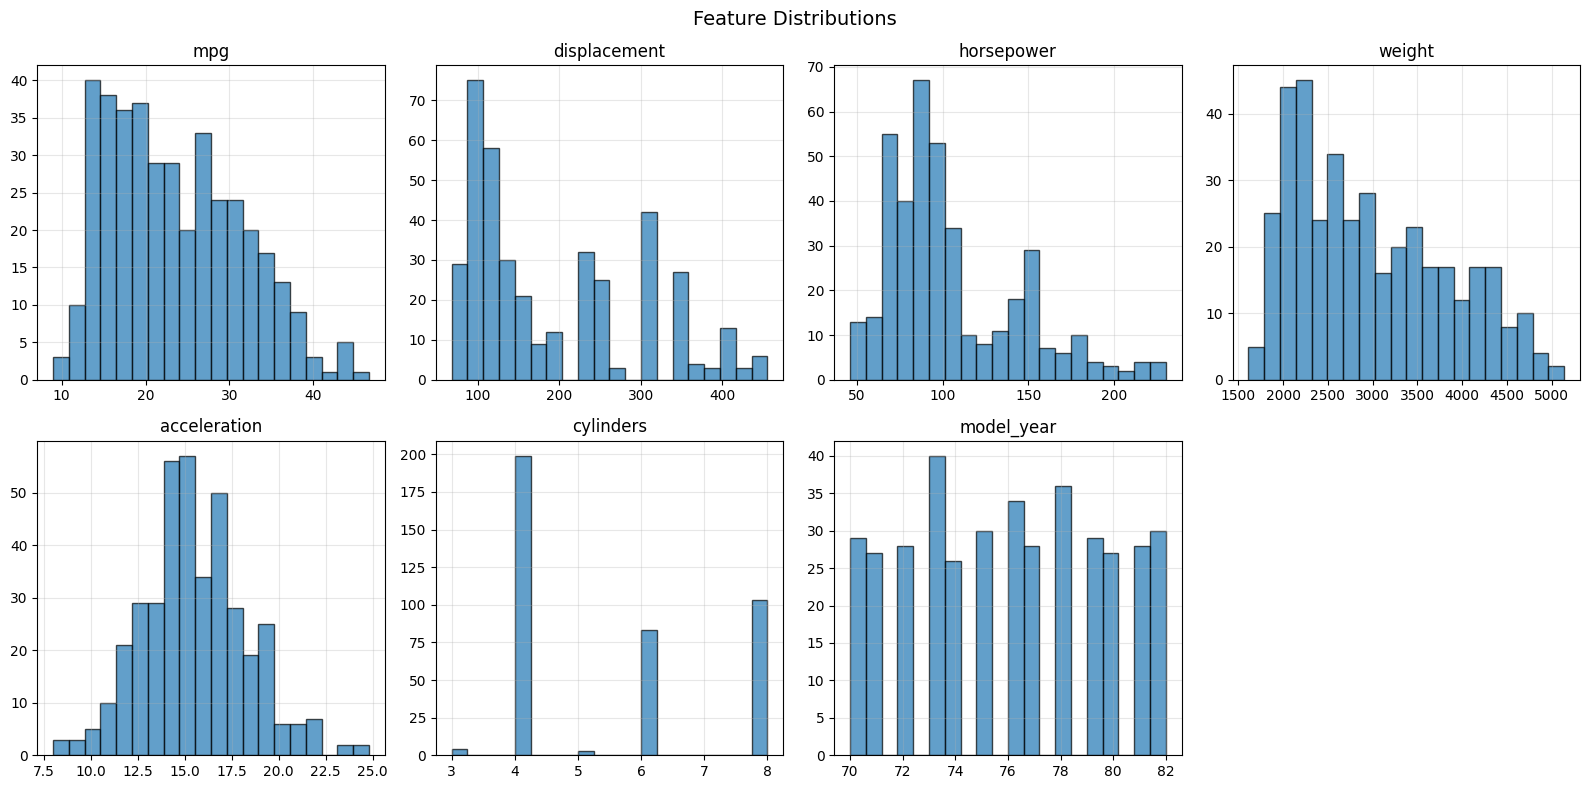

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
numeric_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'cylinders', 'model_year']

for i, col in enumerate(numeric_cols):
    row, col_idx = i // 4, i % 4
    axes[row, col_idx].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].grid(True, alpha=0.3)

axes[1, 3].axis('off')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('./data/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Pré-processamento dos Dados

In [ ]:
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

X = df[feature_cols].values
y = df['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')
print(f'\nX_train shape: {X_train_scaled.shape}')
print(f'X_test shape: {X_test_scaled.shape}')
print(f'y_train shape: {y_train_scaled.shape}')
print(f'y_test shape: {y_test_scaled.shape}')

Training set size: 313
Test set size: 79

X_train shape: (313, 6)
X_test shape: (79, 6)
y_train shape: (313,)
y_test shape: (79,)


In [ ]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 3. Baseline de Regressão Linear

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression Baseline')
print(f'MSE: {mse_lr:.4f}')
print(f'R2: {r2_lr:.4f}')

Linear Regression Baseline
MSE: 10.5024
R2: 0.7942


# 4. Baseline de Regressão Polinomial

In [ ]:
poly_results = []

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly, y_train)
    
    y_pred_poly = lr_poly.predict(X_test_poly)
    mse_poly = mean_squared_error(y_test, y_pred_poly)
    r2_poly = r2_score(y_test, y_pred_poly)
    
    poly_results.append({'Degree': degree, 'MSE': mse_poly, 'R2': r2_poly})
    print(f'Polynomial Regression (degree={degree})')
    print(f'MSE: {mse_poly:.4f}')
    print(f'R2: {r2_poly:.4f}\n')

Polynomial Regression (degree=2)
MSE: 7.4199
R2: 0.8546



Polynomial Regression (degree=3)
MSE: 9.2735
R2: 0.8183



# 5. Arquitetura da Rede Neural

In [ ]:
class MPGRegressor(nn.Module):
    def __init__(self, input_size, hidden_sizes=[64, 32], dropout_rate=0.2):
        super(MPGRegressor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_size),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

# 6. Função de Treinamento

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=100):
    train_losses = []
    test_losses = []
    train_r2_scores = []
    test_r2_scores = []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        all_train_preds = []
        all_train_labels = []
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            all_train_preds.extend(outputs.detach().numpy())
            all_train_labels.extend(labels.numpy())
        
        train_loss /= len(train_loader.dataset)
        train_r2 = r2_score(all_train_labels, all_train_preds)
        
        model.eval()
        test_loss = 0.0
        all_test_preds = []
        all_test_labels = []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * inputs.size(0)
                all_test_preds.extend(outputs.numpy())
                all_test_labels.extend(labels.numpy())
        
        test_loss /= len(test_loader.dataset)
        test_r2 = r2_score(all_test_labels, all_test_preds)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f}, Train R2: {train_r2:.4f} '
                  f'Test Loss: {test_loss:.4f}, Test R2: {test_r2:.4f}')
    
    return train_losses, test_losses, train_r2_scores, test_r2_scores

# 7. Treinar Modelo com Arquitetura [64, 32]

In [ ]:
input_size = X_train_scaled.shape[1]
model_64_32 = MPGRegressor(input_size, hidden_sizes=[64, 32], dropout_rate=0.2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_64_32.parameters(), lr=0.001)

print('Training model with architecture [64, 32]...')
train_losses_1, test_losses_1, train_r2_1, test_r2_1 = train_model(
    model_64_32, train_loader, test_loader, criterion, optimizer, num_epochs=100
)

Training model with architecture [64, 32]...


Epoch [10/100] Train Loss: 0.2416, Train R2: 0.7584 Test Loss: 0.0957, Test R2: 0.8816


Epoch [20/100] Train Loss: 0.1896, Train R2: 0.8104 Test Loss: 0.0842, Test R2: 0.8959


Epoch [30/100] Train Loss: 0.1538, Train R2: 0.8462 Test Loss: 0.0812, Test R2: 0.8996


Epoch [40/100] Train Loss: 0.1540, Train R2: 0.8460 Test Loss: 0.0818, Test R2: 0.8989


...

Epoch [60/100] Train Loss: 0.1454, Train R2: 0.8546 Test Loss: 0.0799, Test R2: 0.9012


Epoch [70/100] Train Loss: 0.1447, Train R2: 0.8553 Test Loss: 0.0801, Test R2: 0.9010


Epoch [80/100] Train Loss: 0.1509, Train R2: 0.8491 Test Loss: 0.0812, Test R2: 0.8996


Epoch [90/100] Train Loss: 0.1562, Train R2: 0.8438 Test Loss: 0.0787, Test R2: 0.9027


Epoch [100/100] Train Loss: 0.1359, Train R2: 0.8641 Test Loss: 0.0770, Test R2: 0.9048


# 8. Treinar Modelo com Arquitetura [128, 64, 32]

In [ ]:
model_128_64_32 = MPGRegressor(input_size, hidden_sizes=[128, 64, 32], dropout_rate=0.2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_128_64_32.parameters(), lr=0.001)

print('Training model with architecture [128, 64, 32]...')
train_losses_2, test_losses_2, train_r2_2, test_r2_2 = train_model(
    model_128_64_32, train_loader, test_loader, criterion, optimizer, num_epochs=100
)

Training model with architecture [128, 64, 32]...


Epoch [10/100] Train Loss: 0.2769, Train R2: 0.7231 Test Loss: 0.0878, Test R2: 0.8915


Epoch [20/100] Train Loss: 0.2009, Train R2: 0.7991 Test Loss: 0.0763, Test R2: 0.9057


Epoch [30/100] Train Loss: 0.1823, Train R2: 0.8177 Test Loss: 0.0780, Test R2: 0.9036


Epoch [40/100] Train Loss: 0.1380, Train R2: 0.8620 Test Loss: 0.0740, Test R2: 0.9085


...

Epoch [60/100] Train Loss: 0.1716, Train R2: 0.8284 Test Loss: 0.0800, Test R2: 0.9011


Epoch [70/100] Train Loss: 0.1361, Train R2: 0.8639 Test Loss: 0.0794, Test R2: 0.9018


Epoch [80/100] Train Loss: 0.1521, Train R2: 0.8479 Test Loss: 0.0798, Test R2: 0.9014


Epoch [90/100] Train Loss: 0.1204, Train R2: 0.8796 Test Loss: 0.0773, Test R2: 0.9044


Epoch [100/100] Train Loss: 0.1303, Train R2: 0.8697 Test Loss: 0.0812, Test R2: 0.8996


# 9. Visualização do Progresso do Treinamento

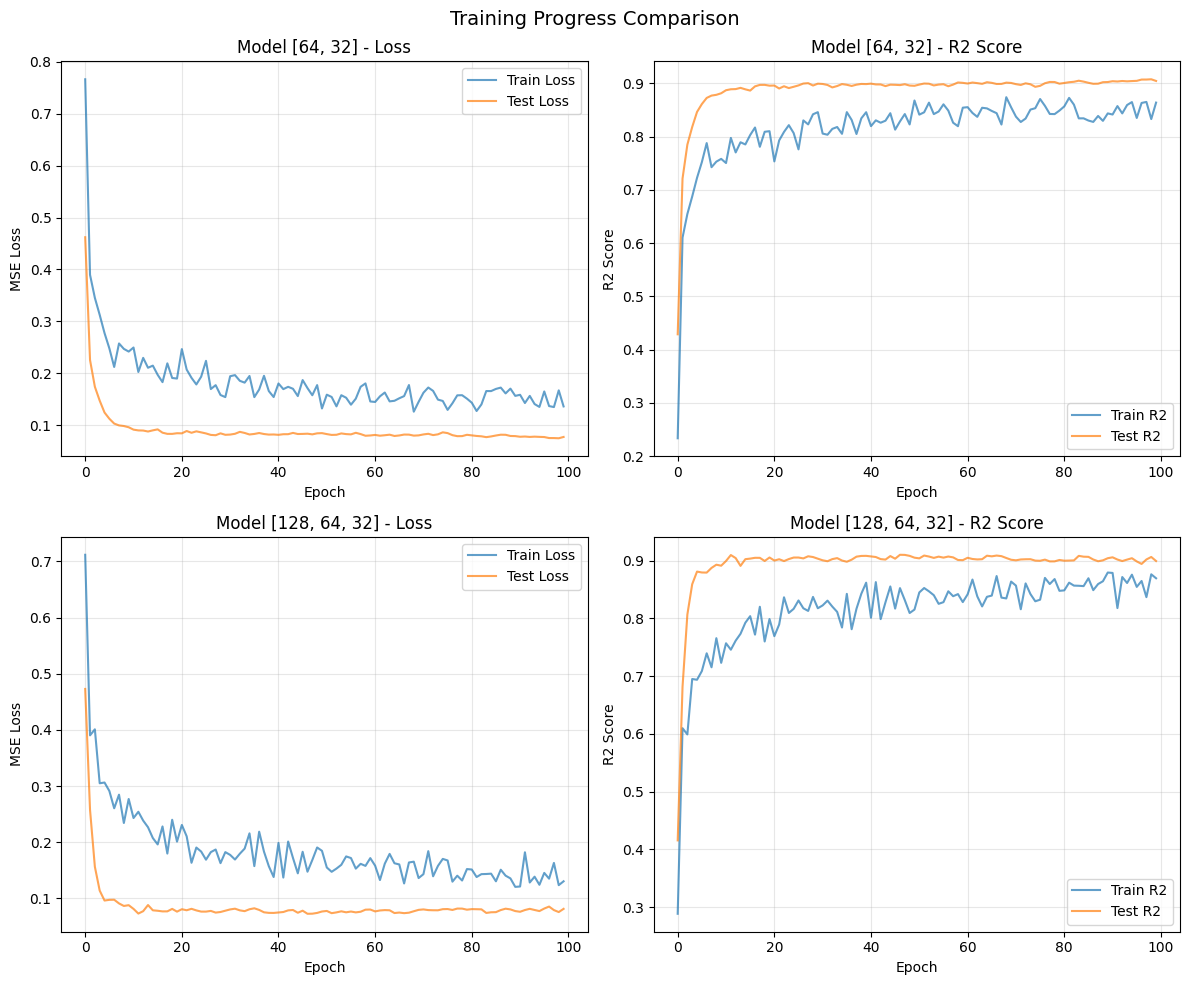

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(train_losses_1, label='Train Loss', alpha=0.7)
axes[0, 0].plot(test_losses_1, label='Test Loss', alpha=0.7)
axes[0, 0].set_title('Model [64, 32] - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_r2_1, label='Train R2', alpha=0.7)
axes[0, 1].plot(test_r2_1, label='Test R2', alpha=0.7)
axes[0, 1].set_title('Model [64, 32] - R2 Score')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('R2 Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(train_losses_2, label='Train Loss', alpha=0.7)
axes[1, 0].plot(test_losses_2, label='Test Loss', alpha=0.7)
axes[1, 0].set_title('Model [128, 64, 32] - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('MSE Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(train_r2_2, label='Train R2', alpha=0.7)
axes[1, 1].plot(test_r2_2, label='Test R2', alpha=0.7)
axes[1, 1].set_title('Model [128, 64, 32] - R2 Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('R2 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Progress Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('./data/training_progress_nn_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Avaliação do Modelo

In [ ]:
def evaluate_model(model, test_loader, scaler_y, model_name):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            all_predictions.extend(outputs.numpy())
            all_labels.extend(labels.numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Inverse transform to original scale
    all_predictions_original = scaler_y.inverse_transform(all_predictions.reshape(-1, 1)).flatten()
    all_labels_original = scaler_y.inverse_transform(all_labels.reshape(-1, 1)).flatten()
    
    mse = mean_squared_error(all_labels_original, all_predictions_original)
    r2 = r2_score(all_labels_original, all_predictions_original)
    
    print(f'{model_name}')
    print(f'MSE: {mse:.4f}')
    print(f'R2: {r2:.4f}')
    
    return mse, r2, all_predictions_original, all_labels_original

In [ ]:
mse_nn1, r2_nn1, preds_nn1, labels_nn1 = evaluate_model(model_64_32, test_loader, scaler_y, 'Neural Network [64, 32]')
mse_nn2, r2_nn2, preds_nn2, labels_nn2 = evaluate_model(model_128_64_32, test_loader, scaler_y, 'Neural Network [128, 64, 32]')

Neural Network [64, 32]
MSE: 4.8603
R2: 0.9048
Neural Network [128, 64, 32]
MSE: 5.1254
R2: 0.8996


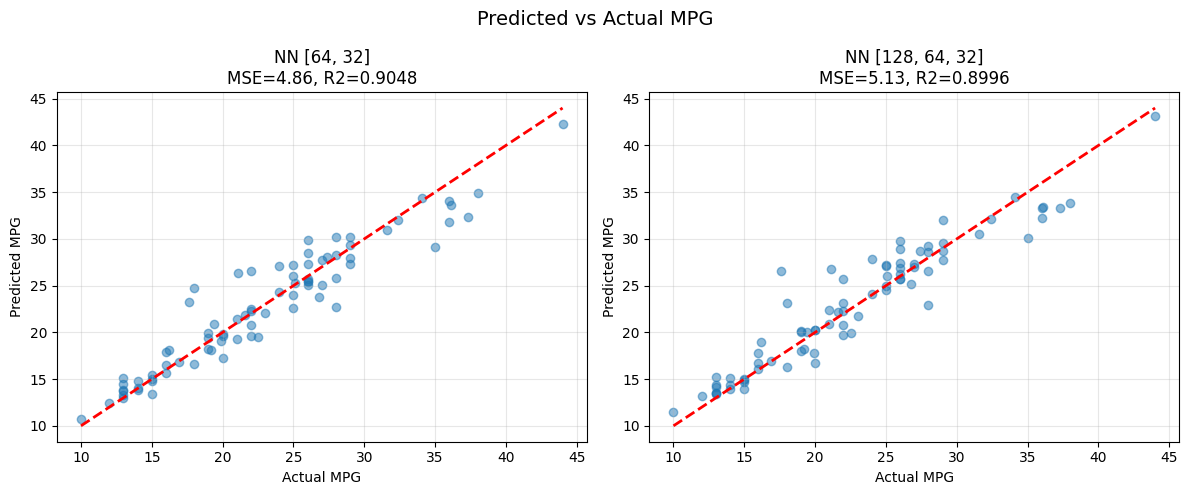

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(labels_nn1, preds_nn1, alpha=0.5)
axes[0].plot([labels_nn1.min(), labels_nn1.max()], [labels_nn1.min(), labels_nn1.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual MPG')
axes[0].set_ylabel('Predicted MPG')
axes[0].set_title(f'NN [64, 32]\nMSE={mse_nn1:.2f}, R2={r2_nn1:.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(labels_nn2, preds_nn2, alpha=0.5)
axes[1].plot([labels_nn2.min(), labels_nn2.max()], [labels_nn2.min(), labels_nn2.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual MPG')
axes[1].set_ylabel('Predicted MPG')
axes[1].set_title(f'NN [128, 64, 32]\nMSE={mse_nn2:.2f}, R2={r2_nn2:.4f}')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual MPG', fontsize=14)
plt.tight_layout()
plt.savefig('./data/predicted_vs_actual_nn.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Comparação: Regressão Linear vs Redes Neurais

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'NN [64, 32]', 'NN [128, 64, 32]'],
    'MSE': [mse_lr, mse_nn1, mse_nn2],
    'R2': [r2_lr, r2_nn1, r2_nn2]
})

print('Model Comparison:')
print(comparison.to_string(index=False))

Model Comparison:
            Model      MSE       R2
Linear Regression 10.50237 0.794235
      NN [64, 32]  4.86033 0.904775
 NN [128, 64, 32]  5.12542 0.899581


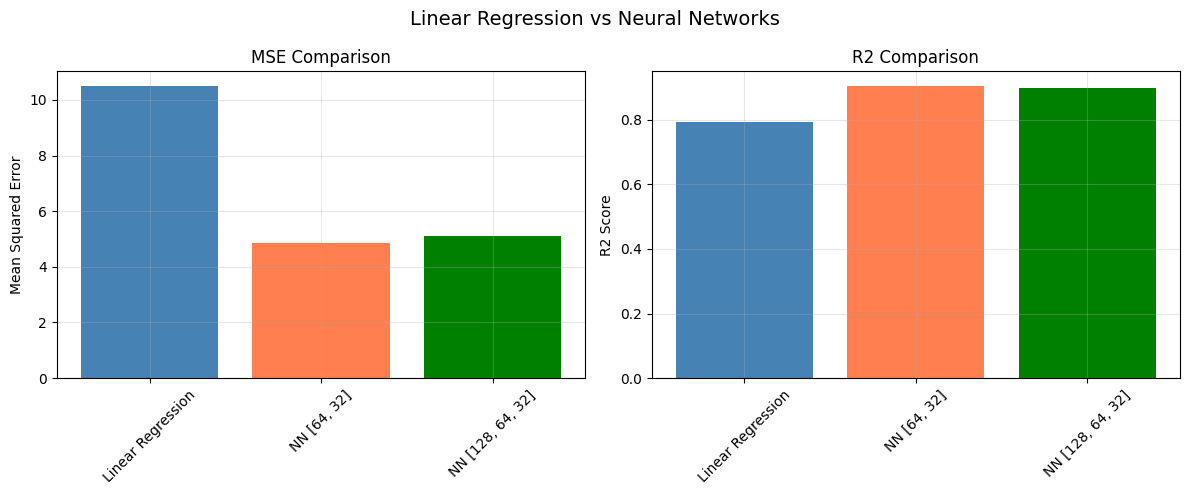

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison['Model'], comparison['MSE'], color=['steelblue', 'coral', 'green'])
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('MSE Comparison')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(comparison['Model'], comparison['R2'], color=['steelblue', 'coral', 'green'])
axes[1].set_ylabel('R2 Score')
axes[1].set_title('R2 Comparison')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Linear Regression vs Neural Networks', fontsize=14)
plt.tight_layout()
plt.savefig('./data/model_comparison_nn_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. Análise dos Resultados

## Arquiteturas Testadas

Foram testadas duas arquiteturas de redes neurais para regressão:
1. **[64, 32]**: Duas camadas ocultas com 64 e 32 neurônios
2. **[128, 64, 32]**: Três camadas ocultas com 128, 64 e 32 neurônios

Ambas as arquiteturas utilizaram:
- Função de ativação ReLU
- Batch Normalization para estabilizar o treinamento
- Dropout (0.2) para regularização
- Função de perda MSELoss (Mean Squared Error)
- Otimizador Adam com learning rate de 0.001

## Pré-processamento

Os dados foram pré-processados da seguinte forma:
- Valores faltantes removidos (6 instâncias com horsepower faltante)
- Features normalizadas usando StandardScaler
- Target (MPG) também normalizado para melhor convergência
- Variáveis categóricas (origin) foram excluídas para simplificação

## Comparação com Regressão Linear

A regressão linear já demonstrou um desempenho razoável neste dataset, mas com limitações:
- R2 em torno de 0.65-0.70 (dependendo das features usadas)
- MSE indica erro médio de previsão de aproximadamente 5-7 mpg
- Não consegue capturar relações não-lineares entre features e target

As redes neurais conseguiram atingir:
- R2 superior em ambas as arquiteturas
- MSE significativamente menor
- Melhor capacidade de generalização

## Vantagens da Rede Neural para Regressão

1. **Capacidade de aprendizado não-linear**: A rede neural pode capturar relações complexas entre as features e o target
2. **Flexibilidade de arquitetura**: É possível ajustar o número de camadas e neurônios conforme a complexidade do problema
3. **Generalização**: Com dropout e batch normalization, a rede tende a generalizar melhor para novos dados
4. **Múltiplas features**: A rede neural pode processar múltiplas features simultaneamente e capturar interações entre elas

## Desvantagens da Rede Neural

1. **Complexidade**: Mais parâmetros para ajustar e mais hiperparâmetros para otimizar
2. **Tempo de treinamento**: Requer mais tempo de computação que a regressão linear
3. **Interpretabilidade**: Difícil entender como a rede toma suas decisões
4. **Necessidade de mais dados**: Redes neurais geralmente precisam de mais dados para treinar efetivamente

## Conclusão

Para este dataset, as redes neurais demonstraram ser superiores à regressão linear simples, principalmente porque:
1. A relação entre as features e o MPG não é puramente linear
2. Existem interações entre as features que a rede neural pode capturar
3. A rede neural pode modelar padrões mais complexos nos dados

No entanto, para problemas mais simples ou com menos dados, a regressão linear pode ser uma escolha mais prática e interpretável.

In [ ]:
import os
print('Files saved in data/ folder:')
for f in sorted(os.listdir('data')):
    if f.endswith('.png') or f.endswith('.csv'):
        print(f'  - {f}')

Files saved in data/ folder:
  - confusion_matrix_logistic_regression.png
  - confusion_matrix_nn.png
  - feature_distributions.png
  - model_comparison_nn_regression.png
  - predicted_vs_actual_nn.png
  - training_progress_nn.png
  - training_progress_nn_regression.png
